<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK7_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 7 — Synthetic Data Generation with ARF**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB5| Pre-generation data transformations |
| NB6 | Synthetic data generation — CTAB-GAN+ |
| **NB7 (this notebook)** | Synthetic data generation — ARF/FORDE |

---

## Notebook overview

| Stage | Section | Description |
|-------|---------|-------------|
| 1 | Libraries | Package imports and environment setup |
| 2 | Configuration | Global parameters, feature sets, variable typing |
| 3 | Build four exclusive cohorts | Mort. 2D, Mort. 7D (exclusive), Mort. 30D (exclusive), Survivors. |
| 4 | Train one ARF model per cohort | Fit ARF adversarial loop → FORDE density estimation (truncated normal per leaf) |
| 5 | Draw N replicas from each fitted generator | Seeded FORGE sampling from each fitted ARF/FORDE model |
| 6 | Post-process to clinical scale | Type enforcement: integer rounding and clipping to observed training range |
| 7 | Run a compact per-replica fidelity screening | Balanced KS (continuous) and TVD (discrete) |
| 8 | Export per replica | `dataset_SYNTH_ARF.csv` |

---
## Objective
Generation of N = 10 synthetic replicas of the prehospital emergency dataset
using ARF. The notebook fits one cohort-specific ARF/FORDE model per exclusive mortality stratum defined by cumulative outcome coding.


## Outputs
- `/DATASET_ARF/dsXX/...` for XX in 01–10
- `/DATASET_ARF/dataset_TEST.csv` (shared real test partition)
- `/DATASET_ARF/generation_metadata.json`
- `/DATASET_ARF/figures/fig_replicas_vs_real.png`


# **What is an Adversarial Random Forest?**

**Adversarial Random Forest (ARF)** is a synthetic data generation method based on Random Forests rather than neural networks. Although it uses an adversarial training idea, it is not a GAN in the strict sense. Instead of training a neural generator and a neural discriminator, ARF trains random forests to progressively distinguish between real and synthetic observations.

The method starts by creating simple synthetic samples from the original data. A random forest is then trained as a discriminator to separate real records from synthetic ones. Based on the tree structure learned in this step, new synthetic samples are generated inside the terminal nodes of the forest. This process is repeated iteratively: at each round, the synthetic data become more similar to the original data, and the discriminator becomes less able to distinguish both groups.

In practical terms, ARF learns a set of tree-based partitions of the feature space. These partitions divide the dataset into smaller regions, or leaves, where the variables are assumed to be locally independent. This does not mean that the model ignores relationships between variables. Instead, dependencies are captured by the forest structure itself: the trees define regions of the data space in which specific combinations of clinical variables tend to occur together.

Once the adversarial forest has been fitted, ARF uses two additional steps:

- **FORDE** (*Forests for Density Estimation*): estimates the probability distribution of the variables inside the terminal leaves of the forest. Continuous variables are modelled using local density functions, whereas categorical or discrete variables are represented using frequency-based probability tables.
- **FORGE** (*Forests for Generative Modelling*): samples new synthetic records from the density model estimated by FORDE.

Therefore, the complete workflow can be summarised as:

1. train an adversarial random forest on the real data;
2. estimate local density parameters with `forde()`;
3. generate synthetic observations with `forge()`.

This separation between model fitting and sampling is useful because the density model only needs to be estimated once. Afterwards, several synthetic replicas can be generated by changing the random seed during the sampling step.


# Model selection: *Why ARF as a second generator?*

ARF was selected as a second generator because it provides a tree-based alternative to CTAB-GAN+. While CTAB-GAN+ follows a neural adversarial approach, ARF uses random forests to learn partitions of the feature space and estimate local data distributions. This makes both models complementary rather than directly equivalent.

The main reasons for including ARF are:

1. **Different modelling approach**: ARF is non-parametric and tree-based, whereas CTAB-GAN+ is based on neural networks. Comparing both methods allows the evaluation of two different strategies for synthetic tabular data generation.

2. **Suitability for mixed clinical data**: ARF can work with continuous, ordinal, binary, and categorical variables with less preprocessing than GAN-based models. This is useful for a heterogeneous clinical dataset such as `dataset_FINAL.csv`.

3. **Lower practical complexity**: ARF requires fewer training decisions than CTAB-GAN+, which is more sensitive to encoding, hyperparameters, training instability, and computational resources.

4. **Useful for small cohorts**: the mortality cohorts are relatively small and imbalanced. A tree-based generator may be more stable and easier to train under these conditions than a fully neural generator.

5. **Multiple replicas from one fitted model**: after fitting ARF and estimating the density model with FORDE, several synthetic datasets can be generated with FORGE by changing the random seed.

Overall, ARF was included to provide a simpler, tree-based comparison against CTAB-GAN+. Its role in this project is not to replace the GAN approach, but to test whether a non-neural generator can better preserve the structure of small mixed-type clinical cohorts.

## **1. Libraries and environment setup**

The following libraries are required. **Section 1** installs the pinned `arfpy` version if needed and records the runtime environment in `generation_metadata.json`.

| Library | Role |
|---------|------|
| `arfpy` | Adversarial Random Forest — density estimation (FORDE) and generation (FORGE). Watson et al. (2023) |
| `pandas`, `numpy` | Tabular data handling, numerical operations, random seed management |
| `json` | Write generation metadata consumed by NB8/NB9 |
| `time` | Wall-clock profiling of fit and sampling phases |
| `platform`, `importlib.metadata` | Environment metadata: Python version and package versions |
| `sklearn.model_selection` | `train_test_split` for deterministic per-cohort partitioning |
| `scipy.stats` | `ks_2samp` for the balanced Kolmogorov–Smirnov fidelity statistic |
| `matplotlib`, `seaborn` | Distribution comparison plots (section 14); saved as PNG artefacts |


In [ ]:

"""
PURPOSE : Install the pinned arfpy package and expose
          collect_environment_metadata() for provenance tracking.

Outputs : arfpy module imported, collect_environment_metadata() (callable).
"""
# ══════════════════════════════════════════════════════════════════════════════
# 1.1 — Install pinned ARF package and expose environment metadata
# ══════════════════════════════════════════════════════════════════════════════
import subprocess
import sys
import os
import platform
import importlib.metadata as importlib_metadata
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ

ARFPY_VERSION_PIN = "0.1.1"
PYTHON_PACKAGE_PINS = [f"arfpy=={ARFPY_VERSION_PIN}"]

try:
    import arfpy
    _installed_arfpy = importlib_metadata.version("arfpy")
    if _installed_arfpy != ARFPY_VERSION_PIN:
        raise ImportError(f"arfpy {_installed_arfpy} != pinned {ARFPY_VERSION_PIN}")
except Exception:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", f"arfpy=={ARFPY_VERSION_PIN}"],
        check=True,
    )
    import arfpy

_PACKAGE_DISTRIBUTIONS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "arfpy": "arfpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

def _package_version(distribution_name: str) -> str | None:
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return None

def collect_environment_metadata() -> dict:
    """Return the runtime metadata exported with generation_metadata.json."""
    return {
        "python": sys.version.replace("\n", " "),
        "platform": platform.platform(),
        "is_colab": bool(IS_COLAB),
        "packages": {
            import_name: _package_version(dist_name)
            for import_name, dist_name in _PACKAGE_DISTRIBUTIONS.items()
        },
        "pip_pins": PYTHON_PACKAGE_PINS,
    }

print(f"✓ arfpy pinned at {ARFPY_VERSION_PIN}")
print("✓ Environment metadata helper ready.")


✓ arfpy pinned at 0.1.1
✓ Environment metadata helper ready.


In [ ]:
"""
PURPOSE : Import all libraries required by NB7.

Libraries
---------
numpy, pandas          — data handling and numerical operations.
arfpy                  — Adversarial Random Forest (density estimation + generation).
sklearn                — train/test splitting.
scipy                  — KS test, truncated normal distribution.
matplotlib, seaborn    — distribution comparison plots.
"""

from __future__ import annotations

import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from typing import Dict, List
from IPython.display import display

# ── ARF ───────────────────────────────────────────────────────────────────────
from arfpy import arf

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# ── Statistical tests ─────────────────────────────────────────────────────────
from scipy.stats import ks_2samp
import scipy

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

print("arfpy imported successfully.")
print(f"Running in {'Google Colab' if IS_COLAB else 'local environment'}.")
print("Note: ARF/FORDE/FORGE runs on CPU.")

arfpy imported successfully.
Running in Google Colab.
Note: ARF/FORDE/FORGE runs on CPU.


### Global plot style

A unified `rcParams` dictionary (`TFG_STYLE`) is applied at the start of every plotting notebook via `mpl.rcParams.update()` and `sns.set_theme()`. This ensures that all figures share the same typographic and colour conventions regardless of cell execution order.

Key design decisions:
- **Serif font** (`DejaVu Serif` / `Times New Roman`): matches the thesis document style and improves legibility in printed figures.
- **White background with thin grid**: avoids grey-background seaborn defaults that reduce contrast in greyscale prints.
- **Fixed DPI** (screen: 100, save: 150): balances render speed with export quality.
- **Shared Real / Synthetic colour pair** (`COLOUR_REAL = #3366CC` blue, `COLOUR_SYNTH = #d62728` red): used consistently in all distribution comparison plots (section 14).


In [ ]:
# ── TFG Unified Plot Style ─────────────────────────────────────────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── Shared colours for Real vs Synthetic comparison ───────────────────
COLOUR_REAL  = "#3366CC"
COLOUR_SYNTH = "#d62728"

print("TFG plot style applied.")


TFG plot style applied.


## **2. Configuration**

Central parameter panel. All **ARF** hyperparameters and pipeline settings are defined here in a single block. Downstream cells read from these variables directly so that a single edit propagates consistently across the pipeline.

### **Execution strategy**

**ARF** is CPU-only. All cohorts are trained sequentially in-process. No multiprocessing is required because **ARF** training is fast compared to **CTAB-GAN+**.

### Cohort design

Cohorts are defined by exclusive cumulative filters identical to **NB6**:
- Mort. 2D: `2D = 1` (implies 7D = 1, 30D = 1 by cumulative coding).
- Mort. 7D: `7D = 1 AND 2D = 0` (exclusive).
- Mort. 30D: `30D = 1 AND 7D = 0` (exclusive).
- Survivors: all outcomes = 0.

Exclusive partitioning ensures no patient appears in more than one positive cohort, preserving correct prevalence in the assembled synthetic dataset.

### Per-cohort hyperparameters (`COHORT_ARF_OVERRIDES`)

Values obtained by incremental single-parameter tuning validated through the generation-time balanced KS/TVD screening. Do not modify without re-running the screening section.

- **`num_trees`**: ensemble size (115–200 per cohort). More trees → stabler density estimates.
- **`delta` = 0.05**: convergence tolerance; relaxed from Watson et al. (2023) default of 0.
- **`max_iters`**: maximum adversarial retraining rounds.
- **`min_node_size`**: minimum observations per leaf; controls density granularity.

### Balanced screening parameters

`KS_EVAL_MAX_N = 500` for replicas with n = 1781. The operational threshold (`KS_MEDIAN_THRESHOLD = 0.20`) is shared with **NB6** for cross-generator comparability.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# NB7 — CONFIGURATION (exclusive cumulative cohort version)
# ══════════════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────────────
if IS_COLAB:
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/TFG/"
else:
    BASE_DIR = "./data/"

DATA_PATH = Path("/content/dataset_FINAL.csv")
OUT_DIR   = BASE_DIR

# ── Global split ──────────────────────────────────────────────────────────────
TRAIN_RATIO: float = 0.75
TEST_RATIO:  float = 0.25
RANDOM_SEED: int   = 42
N_SYNTH_DATASETS: int = 10      # Number of synthetic replicas to generate (set to 10 for final run)
SPLIT_MIN_SIZE: int = 30  # Minimum rows to apply train/test split; below this threshold all data goes to train


# ── Replica seeds ──────────────────────────────────────────────────────────────
# NumPy >=1.17 recommended pattern: statistically independent sub-streams
# spawned from a single master SeedSequence. This preserves full
# reproducibility (single master seed = RANDOM_SEED) while guaranteeing
# that the replicas use reproducible, non-exclusive RNG sub-streams.
_master_ss = np.random.SeedSequence(RANDOM_SEED)
REPLICA_SEEDS: list[int] = [
    int(child.generate_state(1)[0])
    for child in _master_ss.spawn(N_SYNTH_DATASETS)
]

# ── Synthetic size control ────────────────────────────────────────────────────
MAX_SYNTH_TO_TRAIN_RATIO: float = 1.0  # n_synth ≤ ratio × n_train

# ── ARF defaults ──────────────────────────────────────────────────────────────
ARF_DEFAULTS: dict = {
    "num_trees":    115,   # Ensemble trees; more → stabler density estimates
    "delta":        0.05,  # Convergence tolerance: training stops when classifier accuracy
                           # falls to ≤ 1/2 + δ, i.e. the data are locally indistinguishable
                           # from independent marginal samples (Bayes risk ≈ 1/2)
    "max_iters":    15,    # Maximum adversarial retraining rounds
    "min_node_size": 5,    # Minimum observations per leaf; controls density granularity
}
# Per-cohort overrides: add entries here only if a cohort needs parameters
# different from ARF_DEFAULTS. Currently all cohorts use the same configuration.
COHORT_ARF_OVERRIDES: dict = {
    "Mort. 2D":  {"num_trees": 130, "min_node_size": 15, "delta": 0.05, "max_iters": 15},
    "Mort. 7D":  {"num_trees": 130, "min_node_size": 15, "delta": 0.05, "max_iters": 15},
    "Mort. 30D": {"num_trees": 130, "min_node_size": 15, "delta": 0.05, "max_iters": 15},
    "survivors":  {"num_trees": 200, "min_node_size": 15, "delta": 0.05, "max_iters": 20},
}

# ── FORDE / FORGE ─────────────────────────────────────────────────────────────
FORDE_PARAMS: dict = {
    "oob":   False,   # Out-of-bag; False avoids arfpy bug with x_real vs x
    "alpha": 0.0,     # Laplace smoothing for categoricals; 0 = pure empirical frequency
}
FORGE_SD_FLOOR: float = 1e-12  # σ floor for single-observation leaves; prevents division by zero
CFG_CLIP_RANGE: bool  = True   # Clip synthetic values to the observed training range (clinical plausibility)

# ── Balanced screening thresholds ─────────────────────────────────────────────
KS_REFERENCE_SPLIT: str  = "train_model"  # Reference partition for fidelity comparison
KS_EVAL_REPEATS:    int  = 25              # Repetitions of balanced subsampling
KS_EVAL_MAX_N:      int  = 500             # Max subsample size per side (ARF
                                            # operates on larger cohorts; D_crit ≈ 0.086 at n=500)
KS_MEDIAN_THRESHOLD:  float = 0.20         # Operational threshold on the median KS D-statistic
TVD_MEDIAN_THRESHOLD: float = 0.20         # Operational threshold on the median TVD for discrete variables

# ── Plotting ──────────────────────────────────────────────────────────────────
CFG_PLOT: bool = True
PLOT_ALL_REPLICAS: bool = True  # set True to save one figure per replica

print("NB7 — ARF Configuration (exclusive cumulative cohorts)")
print("-" * 60)
print(f"  Input file          : {DATA_PATH}")
print(f"  Output dir          : {OUT_DIR}")
print(f"  Train / test split  : {TRAIN_RATIO:.0%} / {TEST_RATIO:.0%}")
print(f"  N_SYNTH_DATASETS    : {N_SYNTH_DATASETS}")
print(f"  Max synth/train     : {MAX_SYNTH_TO_TRAIN_RATIO}")
print(f"  ARF defaults        : {ARF_DEFAULTS}")
print(f"  FORDE params        : {FORDE_PARAMS}")
print(f"  KS median threshold : {KS_MEDIAN_THRESHOLD}")
print(f"  TVD median threshold: {TVD_MEDIAN_THRESHOLD}")
print(f"  Balanced KS repeats : {KS_EVAL_REPEATS} / max_n={KS_EVAL_MAX_N}")
print("-" * 60)


NB7 — ARF Configuration (exclusive cumulative cohorts)
------------------------------------------------------------
  Input file          : /content/dataset_FINAL.csv
  Output dir          : /content/drive/MyDrive/Colab Notebooks/TFG/
  Train / test split  : 75% / 25%
  N_SYNTH_DATASETS    : 10
  Max synth/train     : 1.0
  ARF defaults        : {'num_trees': 115, 'delta': 0.05, 'max_iters': 15, 'min_node_size': 5}
  FORDE params        : {'oob': False, 'alpha': 0.0}
  KS median threshold : 0.2
  TVD median threshold: 0.2
  Balanced KS repeats : 25 / max_n=500
------------------------------------------------------------


## **3. Data loading**

The cleaned dataset `dataset_FINAL.csv` is loaded directly,
bypassing the pre-generation transformations applied in **NB5**. ARF handles
mixed-type tabular data natively and generates samples on the original clinical
scale, so no scaling or one-hot encoding is required upstream. That said, any
preprocessing step that improved KS or TVD fidelity would have been incorporated.


In [ ]:
# ── Mount Drive (Colab only) ──────────────────────────────────────────────────
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✓ Google Drive mounted")

# ── Validate file existence ───────────────────────────────────────────────────
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Run NB1 first to generate dataset_FINAL.csv."
    )

# ── Load ──────────────────────────────────────────────────────────────────────
df_real = pd.read_csv(DATA_PATH)
print(f"✓ Dataset loaded: {df_real.shape[0]} rows × {df_real.shape[1]} columns")

# Expected NB1 final table
if df_real.shape[0] != 2376:
    print(f"  ⚠ Expected 2376 rows (got {df_real.shape[0]}). Verify data source.")
if df_real.shape[1] != 33:
    print(f"  ⚠ Expected 33 columns (got {df_real.shape[1]}). Verify preprocessing pipeline.")

Mounted at /content/drive
✓ Google Drive mounted
✓ Dataset loaded: 2376 rows × 33 columns


## **4. Variable classification and dtype declaration**

Variables are classified into four types and their pandas dtypes are set
accordingly. ARF uses dtype information internally to determine the appropriate
density estimation strategy for each column.

| Type | Columns | Dtype | ARF treatment |
|------|---------|-------|---------------|
| Continuous | Physiological measurements | `float64` | Truncated normal per leaf |
| Binary | Interventions, sex | `int64` | Empirical frequency |
| Categorical | Ritmo, ST | `category` | Empirical frequency |
| Ordinal | GCS and sub-scores | `int64` | Treated as continuous (truncnorm per leaf) |
| Outcomes | Mort. 2D, 7D, 30D | `int64` | Fixed post-generation (not learned per cohort) |

An assertion verifies that every column in the dataset is assigned to exactly one type, catching any future schema changes early.

**Note on ordinal variables:** ordinal columns (GCS, GCS.V, GCS.M, GCS.O)
remain as `int64` and are therefore treated as continuous by ARF (truncated
normal per leaf). This is a known limitation for ceiling-concentrated ordinal
variables like GCS, where the distribution mass is heavily concentrated at the
maximum value. The resulting fidelity failures for GCS columns are a structural
data limitation, not a tuning problem.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 4 — Variable classification and dtype declaration
# ══════════════════════════════════════════════════════════════════════════════

OUTCOMES = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]

BINARY_COLS = [
    "Sexo",
    "O2", "Gafas", "Resrv.", "Venturi", "O2 sup.",
    "MAVA", "VM", "IOT", "VNI",
    "VAD", "Nebul.", "TTE",
]

CATEGORICAL_COLS = ["Ritmo", "ST"]
ORDINAL_COLS     = ["GCS", "GCS.V", "GCS.M", "GCS.O"]

CONTINUOUS_COLS = sorted([
    c for c in df_real.columns
    if c not in OUTCOMES + BINARY_COLS + CATEGORICAL_COLS + ORDINAL_COLS
])

FEATURE_COLS = [c for c in df_real.columns if c not in OUTCOMES]
FINAL_EXPORT_COLS = FEATURE_COLS + [c for c in OUTCOMES if c not in FEATURE_COLS]

all_classified = set(
    CONTINUOUS_COLS + BINARY_COLS + CATEGORICAL_COLS + ORDINAL_COLS + OUTCOMES
)
assert all_classified == set(df_real.columns), (
    f"Unclassified columns: {set(df_real.columns) - all_classified}"
)

print("✓ All columns classified.")
print(f"  Continuous  ({len(CONTINUOUS_COLS)}): {CONTINUOUS_COLS}")
print(f"  Binary      ({len(BINARY_COLS)}): {BINARY_COLS}")
print(f"  Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"  Ordinal     ({len(ORDINAL_COLS)}): {ORDINAL_COLS}")
print(f"  Outcomes    ({len(OUTCOMES)}): {OUTCOMES}")
print(f"  Feature cols({len(FEATURE_COLS)}): base columns used in every cohort")
print("  Note: outcome columns are excluded from model_cols and reattached as fixed cohort labels.")

df_typed = df_real.copy()

for col in CATEGORICAL_COLS:
    df_typed[col] = df_typed[col].astype("category")

for col in ORDINAL_COLS:
    df_typed[col] = pd.to_numeric(df_typed[col], errors="coerce").round().astype("int64")

for col in BINARY_COLS + OUTCOMES:
    df_typed[col] = pd.to_numeric(df_typed[col], errors="coerce").round().astype("int64")

print("\nDtype summary:")
print(df_typed.dtypes.value_counts().to_string())
print(f"\n✓ Typed dataframe ready: {df_typed.shape}")


✓ All columns classified.
  Continuous  (11): ['Edad', 'FC', 'FR', 'FiO2', 'Glucemia', 'Lactato', 'SpO2', 'TAD', 'TAM', 'TAS', 'TT']
  Binary      (13): ['Sexo', 'O2', 'Gafas', 'Resrv.', 'Venturi', 'O2 sup.', 'MAVA', 'VM', 'IOT', 'VNI', 'VAD', 'Nebul.', 'TTE']
  Categorical (2): ['Ritmo', 'ST']
  Ordinal     (4): ['GCS', 'GCS.V', 'GCS.M', 'GCS.O']
  Outcomes    (3): ['Mort. 2D', 'Mort. 7D', 'Mort. 30D']
  Feature cols(30): base columns used in every cohort
  Note: outcome columns are excluded from model_cols and reattached as fixed cohort labels.

Dtype summary:
int64       27
float64      4
category     1
category     1

✓ Typed dataframe ready: (2376, 33)


## **5. Integrity verification**

Basic data quality checks before any processing:

- **Missing values**: the dataset is expected to be complete after **NB1** preprocessing.
  Any missing values would require revisiting the cleaning pipeline.
- **Outcome prevalence**: reported for reference and comparison with synthetic
  prevalence in **section 13**.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 5 — Integrity verification
# ══════════════════════════════════════════════════════════════════════════════

n_missing = int(df_typed.isnull().sum().sum())
if n_missing > 0:
    print(f"⚠ Missing values detected ({n_missing} total):")
    display(df_typed.isnull().sum()[df_typed.isnull().sum() > 0].sort_values(ascending=False))
else:
    print("✓ No missing values.")

print("\nOutcome prevalence (real dataset):")
print("-" * 44)
for col in OUTCOMES:
    n_pos = int(df_typed[col].sum())
    pct   = df_typed[col].mean() * 100
    print(f"  {col:<12}: {n_pos:>4} positive  ({pct:.2f}%)")

# Cumulative coding check
v1 = int(((df_typed["Mort. 2D"] == 1) & (df_typed["Mort. 7D"]  == 0)).sum())
v2 = int(((df_typed["Mort. 7D"] == 1) & (df_typed["Mort. 30D"] == 0)).sum())
assert v1 == 0, f"Monotonicity violated (2D→7D): {v1} cases in real data"
assert v2 == 0, f"Monotonicity violated (7D→30D): {v2} cases in real data"
print("\n✓ Cumulative mortality monotonicity verified in real data.")


✓ No missing values.

Outcome prevalence (real dataset):
--------------------------------------------
  Mort. 2D    :  114 positive  (4.80%)
  Mort. 7D    :  173 positive  (7.28%)
  Mort. 30D   :  261 positive  (10.98%)

✓ Cumulative mortality monotonicity verified in real data.


## **6. Cohort construction**

The dataset is divided into **4 mutually exclusive cohorts** using cumulative outcome filters. This mirrors the design of **NB6** (**CTAB-GAN+**).

| Cohort | Filter | Notes on outcome handling |
|--------|--------|---------------------------|
| `Mort. 2D` | `Mort. 2D == 1` | All outcomes fixed to 1 (cumulative: 2D=1 implies 7D=1 and 30D=1) |
| `Mort. 7D` (excl.) | `Mort. 7D == 1 AND Mort. 2D == 0` | 2D fixed 0; 7D and 30D fixed 1 |
| `Mort. 30D` (excl.) | `Mort. 30D == 1 AND Mort. 7D == 0` | 2D and 7D fixed 0; 30D fixed 1 |
| `survivors` | All outcomes = 0 | All outcomes fixed to 0 |

**Key properties of the exclusive design:**
1. No patient appears in more than one mortality cohort.
2. The assembled synthetic dataset preserves prevalence proportions of the real dataset.
3. All outcome columns are fixed during generation (`varying_outcomes = []`), avoiding outcome-generation leakage within each cohort.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 6 — Cohort construction (exclusive cumulative filters)
#
# Mort. 2D  : 2D=1 (implies 7D=1, 30D=1)
# Mort. 7D  : 7D=1 AND 2D=0  (exclusive)
# Mort. 30D : 30D=1 AND 7D=0 (exclusive)
# Survivors : all outcomes = 0
#
# All outcome columns are fixed during generation (varying_outcomes = []).
# ════════════════════════════════════════════

cohorts = {
    # Mort. 2D: all 2D=1 (cumulative: also 7D=1, 30D=1)
    "Mort. 2D": {
        "df_full":          df_typed.loc[df_typed["Mort. 2D"] == 1].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 1, "Mort. 7D": 1, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 2D",
    },
    # Mort. 7D exclusive: 7D=1 AND 2D=0
    "Mort. 7D": {
        "df_full":          df_typed.loc[
                                (df_typed["Mort. 7D"] == 1) & (df_typed["Mort. 2D"] == 0)
                            ].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 1, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 7D",
    },
    # Mort. 30D exclusive: 30D=1 AND 7D=0
    "Mort. 30D": {
        "df_full":          df_typed.loc[
                                (df_typed["Mort. 30D"] == 1) & (df_typed["Mort. 7D"] == 0)
                            ].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 0, "Mort. 30D": 1},
        "endpoint_target":  "Mort. 30D",
    },
    "survivors": {
        "df_full":          df_typed.loc[
                                (df_typed["Mort. 2D"] == 0) &
                                (df_typed["Mort. 7D"] == 0) &
                                (df_typed["Mort. 30D"] == 0)
                            ].reset_index(drop=True),
        "model_cols":       FEATURE_COLS,
        "varying_outcomes": [],
        "fixed_outcomes":   {"Mort. 2D": 0, "Mort. 7D": 0, "Mort. 30D": 0},
        "endpoint_target":  None,
    },
}

print("Cohort summary (exclusive cumulative filters):")
print("-" * 88)
print(f"  {'Cohort':<12} {'Rows':>8} {'Model cols':>11}  Notes")
print("-" * 88)
for name, info in cohorts.items():
    note = ""
    if name == "survivors":
        n_all = len(df_typed.loc[
            (df_typed["Mort. 2D"] == 0) & (df_typed["Mort. 7D"] == 0) & (df_typed["Mort. 30D"] == 0)])
        note = f"all {n_all} (no cap)"
    if name == "Mort. 7D":
        note = "exclusive: 7D=1 & 2D=0"
    if name == "Mort. 30D":
        note = "exclusive: 30D=1 & 7D=0"
    print(f"  {name:<12} {len(info['df_full']):>8} {len(info['model_cols']):>11}  {note}")
print("-" * 88)
print()


Cohort summary (exclusive cumulative filters):
----------------------------------------------------------------------------------------
  Cohort           Rows  Model cols  Notes
----------------------------------------------------------------------------------------
  Mort. 2D          114          30  
  Mort. 7D           59          30  exclusive: 7D=1 & 2D=0
  Mort. 30D          88          30  exclusive: 30D=1 & 7D=0
  survivors        2115          30  all 2115 (no cap)
----------------------------------------------------------------------------------------



## **7. Train/test split by cohort**

Each cohort is split into a **training partition** (75 %) and a **held-out test partition** (25 %) using `sklearn.model_selection.train_test_split` with a fixed random seed (`RANDOM_SEED = 42`). Cohorts with fewer than `SPLIT_MIN_SIZE` rows are not split; all rows go to training.

Only the **training partition** is passed to ARF for density estimation. The test partition is preserved untouched for downstream TSTR evaluation in **NB9**, ensuring that the generator is never exposed to evaluation data.

The random seed and split ratio are identical to **NB6** (CTAB-GAN+) so that both generators are evaluated against the same real held-out partition. With exclusive cohorts there are no structural duplicate patients across cohort test sets.

The columns passed to ARF correspond to `model_cols = FEATURE_COLS`, excluding all outcome columns. Outcome columns are fixed per cohort and contribute no information to the density estimator.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 7 — Train/test split by cohort
# ══════════════════════════════════════════════════════════════════════════════

def split_cohort_train_test(cohort_df: pd.DataFrame,
                            train_ratio: float = TRAIN_RATIO,
                            random_state: int  = RANDOM_SEED,
                            min_size: int      = SPLIT_MIN_SIZE) -> dict:
    """
    Split a cohort DataFrame into train and test partitions.

    Parameters
    ----------
    cohort_df : pd.DataFrame
        Full cohort dataset to split.
    train_ratio : float, optional
        Fraction of rows allocated to training. Default TRAIN_RATIO (0.75).
    random_state : int, optional
        Random seed for reproducible splits. Default RANDOM_SEED (42).
    min_size : int, optional
        Minimum cohort size to apply a split. Below this threshold all rows
        go to training. Default SPLIT_MIN_SIZE.

    Returns
    -------
    dict
        Keys: train_full, test_full (pd.DataFrame), sizes (dict with
        'train' and 'test' counts), split_applied (bool).

    Notes
    -----
    Dynamic model column selection (train_model / test_model) is applied
    by the caller using info['model_cols']. The split is deterministic given
    random_state; no stratification is applied because cohort membership
    already guarantees a fixed outcome. This function is signature-compatible
    with its NB6 counterpart so that both generators use the identical split.
    """
    if len(cohort_df) < min_size:
        return {
            "train_full": cohort_df.copy(),
            "test_full":  pd.DataFrame(columns=cohort_df.columns),
            "sizes": {"train": len(cohort_df), "test": 0},
            "split_applied": False,
        }

    train_df, test_df = train_test_split(
        cohort_df,
        train_size=train_ratio,
        random_state=random_state,
        shuffle=True,
    )
    return {
        "train_full": train_df.reset_index(drop=True),
        "test_full":  test_df.reset_index(drop=True),
        "sizes": {"train": len(train_df), "test": len(test_df)},
        "split_applied": True,
    }

# -- Output directories (persistent on Drive) --------------------------
GEN_DIR     = os.path.join(BASE_DIR, "GENERATION", "DATASET_ARF")
COHORTS_OUT = os.path.join(GEN_DIR, "cohorts")
FIGS_OUT    = os.path.join(GEN_DIR, "figures")
os.makedirs(COHORTS_OUT, exist_ok=True)
os.makedirs(FIGS_OUT,    exist_ok=True)

cohort_splits = {}
print("Data splitting summary (train / test):")
print("-" * 88)
print(f"  {'Cohort':<12} {'Train':>8} {'Test':>8} {'Model cols':>11}  Split applied?")
print("-" * 88)

for name, info in cohorts.items():
    splits = split_cohort_train_test(info["df_full"])
    splits["train_model"] = splits["train_full"][info["model_cols"]].copy()
    splits["test_model"]  = splits["test_full"][info["model_cols"]].copy()
    cohort_splits[name] = splits

    sz      = splits["sizes"]
    applied = "yes" if splits["split_applied"] else "no (all -> train)"
    print(f"  {name:<12} {sz['train']:>8} {sz['test']:>8} {len(info['model_cols']):>11}  {applied}")
print("-" * 88)
print(f"\n  4 train partitions ready for ARF fitting.")


Data splitting summary (train / test):
----------------------------------------------------------------------------------------
  Cohort          Train     Test  Model cols  Split applied?
----------------------------------------------------------------------------------------
  Mort. 2D           85       29          30  yes
  Mort. 7D           44       15          30  yes
  Mort. 30D          66       22          30  yes
  survivors        1586      529          30  yes
----------------------------------------------------------------------------------------

  4 train partitions ready for ARF fitting.


## **8. Helper functions**

These functions and methods are prepared to be run on the following parts of the notebook. They have a brief docstring explaining the functionality of each.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 8 — Helper functions
# ══════════════════════════════════════════════════════════════════════════════

def resolve_cohort_arf_params(cohort_name: str) -> dict:
    """
    Return final ARF hyperparameters for a cohort.

    Parameters
    ----------
    cohort_name : str
        Name of the cohort (e.g. "Mort. 2D", "survivors").

    Returns
    -------
    dict
        Keys: num_trees, delta, max_iters, min_node_size.
        ARF_DEFAULTS updated with any COHORT_ARF_OVERRIDES for this cohort.

    Notes
    -----
    Only the keys present in the override dict are modified.
    If COHORT_ARF_OVERRIDES is empty, all cohorts use ARF_DEFAULTS unchanged.
    """
    params = ARF_DEFAULTS.copy()
    params.update(COHORT_ARF_OVERRIDES.get(cohort_name, {}))
    return params


def postprocess_synth_model(df_synth: pd.DataFrame,
                             df_train_ref: pd.DataFrame,
                             binary_like_cols: List[str],
                             categorical_cols: List[str],
                             ordinal_cols: List[str],
                             continuous_cols: List[str]) -> pd.DataFrame:
    """
    Apply post-generation type constraints to a synthetic cohort.

    FORGE may produce continuous values for columns that should be integer-valued,
    or out-of-range values for bounded variables. This function enforces:
      - Binary and ordinal: round + clip to observed training range [lo, hi].
      - Categorical: snap unrecognised levels to the first valid training category.
      - Continuous (when CFG_CLIP_RANGE=True): clip to [min_train, max_train].

    Parameters
    ----------
    df_synth : pd.DataFrame
        Raw FORGE output in clinical scale (model cols only).
    df_train_ref : pd.DataFrame
        Training partition used to determine valid ranges and categories.
    binary_like_cols : list of str
        Columns to round and clip to {0, 1}.
    categorical_cols : list of str
        Columns to snap to the observed training category set.
    ordinal_cols : list of str
        Columns to round and clip to their observed integer range.
    continuous_cols : list of str
        Columns to clip to [min_train, max_train] when CFG_CLIP_RANGE is True.

    Returns
    -------
    pd.DataFrame
        Copy of df_synth with all type constraints applied. Never modified in place.
    """
    out = df_synth.copy()

    # Binary and ordinal: round to integer + clip to observed training range
    for col in binary_like_cols + ordinal_cols:
        if col in out.columns:
            lo = int(df_train_ref[col].min())
            hi = int(df_train_ref[col].max())
            out[col] = (
                pd.to_numeric(out[col], errors="coerce")
                .round().clip(lo, hi).fillna(lo).astype("int64")
            )

    # Categorical: snap unknown levels to first valid training category
    for col in categorical_cols:
        if col in out.columns:
            valid_vals = list(df_train_ref[col].astype(str).dropna().unique())
            if not valid_vals:
                continue
            valid_set = set(valid_vals)
            fallback  = valid_vals[0]
            col_str   = out[col].astype(str)
            out[col]  = (
                col_str
                .where(col_str.isin(valid_set), other=fallback)
                .astype("category")
            )

    # Continuous: clip to observed training range
    if CFG_CLIP_RANGE:
        for col in continuous_cols:
            if col in out.columns:
                lo = float(df_train_ref[col].min())
                hi = float(df_train_ref[col].max())
                out[col] = pd.to_numeric(out[col], errors="coerce").clip(lo, hi)

    return out


def assemble_full_schema(df_model_synth: pd.DataFrame, cohort_info: dict) -> pd.DataFrame:
    """
    Reattach fixed outcome columns and align output to FINAL_EXPORT_COLS.

    FORGE generates only the model columns (FEATURE_COLS). This function adds
    back the fixed outcome columns whose values are constant for every row in
    the cohort, then enforces binary range and returns columns in canonical order.

    Parameters
    ----------
    df_model_synth : pd.DataFrame
        Post-processed FORGE output (clinical scale, model cols only).
    cohort_info : dict
        Entry from the cohorts dict, containing "fixed_outcomes".

    Returns
    -------
    pd.DataFrame
        Synthetic data with all FINAL_EXPORT_COLS present and in canonical order.
        All outcome columns are clipped to {0, 1} and cast to int64.
    """
    out = df_model_synth.copy()
    for col, value in cohort_info["fixed_outcomes"].items():
        out[col] = int(value)
    for col in OUTCOMES:
        if col not in out.columns:
            out[col] = 0
        out[col] = (
            pd.to_numeric(out[col], errors="coerce")
            .fillna(0).round().clip(0, 1).astype("int64")
        )
    return out[FINAL_EXPORT_COLS]


def balanced_ks_table(real_df: pd.DataFrame,
                       synth_df: pd.DataFrame,
                       continuous_cols: List[str],
                       n_repeats: int = KS_EVAL_REPEATS,
                       eval_max_n: int | None = KS_EVAL_MAX_N,
                       random_state: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Balanced KS test with repeated subsampling (25 repeats by default).

    Sampling strategy (automatic per column):
      - Subsampling without replacement (replace=False) when eval_max_n caps below
        the cohort size: each repeat draws a distinct subset -> genuine variance.
      - Bootstrap with replacement (replace=True) when the cohort is smaller than
        eval_max_n: without replacement every repeat would draw the full population,
        making all 25 replicates identical. Bootstrap restores variance for small
        mortality cohorts. The "bootstrap" field in the output flags which mode
        was used, ensuring methodological transparency.

    Pass criterion: median D < KS_MEDIAN_THRESHOLD (not the mean).

    Parameters
    ----------
    real_df : pd.DataFrame
        Reference (real) partition in clinical scale.
    synth_df : pd.DataFrame
        Synthetic data from FORGE in clinical scale.
    continuous_cols : list of str
        Columns to evaluate. Missing columns are skipped silently.
    n_repeats : int, optional
        Number of balanced subsampling repetitions. Default KS_EVAL_REPEATS.
    eval_max_n : int or None, optional
        Maximum balanced sample size per side. Default KS_EVAL_MAX_N.
    random_state : int, optional
        Base seed; each repeat uses random_state + rep. Default RANDOM_SEED.

    Returns
    -------
    pd.DataFrame
        One row per column. Columns: column, metric, eval_n, repeats,
        bootstrap, statistic_mean, statistic_median, statistic_p75,
        statistic_max, pass. Sorted descending by statistic_median.
    """
    rows = []
    for col in continuous_cols:
        if col not in real_df.columns or col not in synth_df.columns:
            continue

        rv = pd.to_numeric(real_df[col],  errors="coerce").dropna().to_numpy()
        sv = pd.to_numeric(synth_df[col], errors="coerce").dropna().to_numpy()
        if len(rv) < 2 or len(sv) < 2:
            continue

        n_eval = min(len(rv), len(sv))
        if eval_max_n is not None:
            n_eval = min(n_eval, int(eval_max_n))
        if n_eval < 2:
            continue

        use_bootstrap = (n_eval >= len(rv)) or (n_eval >= len(sv))

        stats = []
        for rep in range(n_repeats):
            rng = np.random.default_rng(random_state + rep)
            rr  = rng.choice(rv, size=n_eval, replace=use_bootstrap)
            ss  = rng.choice(sv, size=n_eval, replace=use_bootstrap)
            stats.append(float(ks_2samp(rr, ss).statistic))

        rows.append({
            "column":           col,
            "metric":           "KS",
            "eval_n":           int(n_eval),
            "repeats":          int(n_repeats),
            "bootstrap":        use_bootstrap,
            "statistic_mean":   float(np.mean(stats)),
            "statistic_median": float(np.median(stats)),
            "statistic_p75":    float(np.percentile(stats, 75)),
            "statistic_max":    float(np.max(stats)),
            "pass":             bool(float(np.median(stats)) < KS_MEDIAN_THRESHOLD),
        })

    if not rows:
        return pd.DataFrame(columns=[
            "column", "metric", "eval_n", "repeats", "bootstrap",
            "statistic_mean", "statistic_median", "statistic_p75",
            "statistic_max", "pass"
        ])
    return (
        pd.DataFrame(rows)
        .sort_values("statistic_median", ascending=False)
        .reset_index(drop=True)
    )


def balanced_tvd_table(real_df: pd.DataFrame,
                        synth_df: pd.DataFrame,
                        discrete_cols: List[str],
                        col_type_map: Dict[str, str] | None = None,
                        n_repeats: int = KS_EVAL_REPEATS,
                        eval_max_n: int | None = KS_EVAL_MAX_N,
                        random_state: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Total Variation Distance for original-scale discrete variables via balanced
    subsampling.

    TVD = 0.5 * sum_k |P_real(k) - P_synth(k)|  (bounded in [0, 1]).
    TVD = 0 -> identical distributions; TVD = 1 -> no shared support.

    Mirrors the balanced-subsampling protocol of balanced_ks_table() for
    methodological symmetry and cross-generator comparability with NB6.
    The function signature is identical to NB6 balanced_tvd_table() to enable
    schema-compatible loading in NB8.

    Parameters
    ----------
    real_df : pd.DataFrame
        Reference (real) partition in clinical scale.
    synth_df : pd.DataFrame
        Synthetic data from FORGE in clinical scale.
    discrete_cols : list of str
        Columns to evaluate (binary, categorical, ordinal).
    col_type_map : dict of {str: str} or None, optional
        Maps column names to type label ("binary", "categorical", "ordinal").
        Populates the "type" field in output for NB8 compatibility. Default None.
    n_repeats : int, optional
        Subsampling repetitions. Default KS_EVAL_REPEATS.
    eval_max_n : int or None, optional
        Max balanced sample size per side. Default KS_EVAL_MAX_N.
    random_state : int, optional
        Base seed. Default RANDOM_SEED.

    Returns
    -------
    pd.DataFrame
        One row per column. Columns: column, type, metric, eval_n, repeats,
        bootstrap, statistic_mean, statistic_median, statistic_p75,
        statistic_max, pass. Sorted descending by statistic_median.
    """
    rows = []

    def _tvd_single_col(rv, sv):
        rp = pd.Series(rv).astype(str).value_counts(normalize=True)
        sp = pd.Series(sv).astype(str).value_counts(normalize=True)
        idx = sorted(set(rp.index).union(sp.index))
        rp = rp.reindex(idx, fill_value=0.0)
        sp = sp.reindex(idx, fill_value=0.0)
        return 0.5 * np.abs(rp.values - sp.values).sum()

    col_type_map = col_type_map or {}

    for col in discrete_cols:
        if col not in real_df.columns or col not in synth_df.columns:
            continue

        rv = real_df[col].dropna().to_numpy()
        sv = synth_df[col].dropna().to_numpy()
        if len(rv) < 2 or len(sv) < 2:
            continue

        n_eval = min(len(rv), len(sv))
        if eval_max_n is not None:
            n_eval = min(n_eval, int(eval_max_n))
        if n_eval < 2:
            continue

        use_bootstrap = (n_eval >= len(rv)) or (n_eval >= len(sv))

        stats = []
        for rep in range(n_repeats):
            rng = np.random.default_rng(random_state + rep)
            rr  = rng.choice(rv, size=n_eval, replace=use_bootstrap)
            ss  = rng.choice(sv, size=n_eval, replace=use_bootstrap)
            stats.append(float(_tvd_single_col(rr, ss)))

        rows.append({
            "column":           col,
            "type":             col_type_map.get(col, "discrete"),
            "metric":           "TVD",
            "eval_n":           int(n_eval),
            "repeats":          int(n_repeats),
            "bootstrap":        use_bootstrap,
            "statistic_mean":   float(np.mean(stats)),
            "statistic_median": float(np.median(stats)),
            "statistic_p75":    float(np.percentile(stats, 75)),
            "statistic_max":    float(np.max(stats)),
            "pass":             bool(float(np.median(stats)) < TVD_MEDIAN_THRESHOLD),
        })

    if not rows:
        return pd.DataFrame(columns=[
            "column", "type", "metric", "eval_n", "repeats", "bootstrap",
            "statistic_mean", "statistic_median", "statistic_p75",
            "statistic_max", "pass"
        ])
    return (
        pd.DataFrame(rows)
        .sort_values("statistic_median", ascending=False)
        .reset_index(drop=True)
    )


def _safe_ratio(num: int, den: int) -> str:
    """
    Format a pass/total integer pair as a "n/d" string.

    Parameters
    ----------
    num : int
        Numerator (number of passing variables).
    den : int
        Denominator (total number of variables). Returns "0/0" if zero.

    Returns
    -------
    str
        Formatted ratio string, e.g. "8/10".
    """
    return f"{int(num)}/{int(den)}" if den else "0/0"


def _pass_symbol(passed: bool) -> str:
    """
    Return a Unicode check or cross symbol for pass/fail display.

    Parameters
    ----------
    passed : bool
        True -> chr(10003) (check); False -> chr(10007) (cross).

    Returns
    -------
    str
        chr(10003) or chr(10007).
    """
    return "✓" if passed else "✗"


print("Helper functions defined (balanced KS + balanced TVD, NB6-compatible schema).")


Helper functions defined (balanced KS + balanced TVD, NB6-compatible schema).


## **9. FORDE / FORGE backends**

After fitting the adversarial random forest, ARF separates density estimation
from synthetic sampling through two steps:

- ***FORDE*** estimates the data distribution inside the terminal leaves of the forest.
- ***FORGE*** generates new synthetic observations from the density model estimated by *FORDE*.

For continuous variables, *FORDE* uses a truncated normal distribution within each leaf. This keeps generated values inside the bounds defined by the tree splits. For categorical variables (`category` dtype), *FORDE* uses empirical category frequencies within each leaf. In this notebook, binary variables are integer-coded and ordinal GCS variables are intentionally kept as `int64`; they are therefore handled through the numeric path during density estimation and then rounded/clipped during post-processing. This choice is documented in section 4 so that the ARF implementation remains directly comparable with the original clinical-scale dataset.

In practical terms, *FORDE* defines a local probability model for each terminal
leaf. FORGE then samples synthetic records by:

1. selecting a tree;
2. selecting a terminal leaf according to its estimated probability;
3. sampling each variable from the corresponding leaf-level distribution.

This means that the fitted *ARF/FORDE* model is shared across replicas, while
differences between synthetic replicas come from the stochastic sampling step in
*FORGE*.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 9 — Density estimation (FORDE) and generation (FORGE)
# ══════════════════════════════════════════════════════════════════════════════


def safe_forde(model, dist: str = "truncnorm", oob: bool = False, alpha: float = 0.0):
    """Robust replacement for arfpy.forde() on mixed clinical data.

    Fixes two arfpy issues that are especially relevant here:
    1) oob=True references self.x, but the class stores self.x_real.
    2) alpha>0 with categorical variables builds pd.DataFrame(self.levels),
       which crashes when categorical variables have different numbers of levels.
    """
    model.dist = dist
    model.oob = oob
    model.alpha = alpha

    # Terminal nodes for all observations
    pred = model.clf.apply(model.x_real)

    # OOB masking (robust version)
    if model.oob:
        from sklearn.ensemble._forest import _generate_unsampled_indices
        for tree in range(model.num_trees):
            n_obs = model.x_real.shape[0]
            idx_oob = np.isin(
                range(n_obs),
                _generate_unsampled_indices(
                    model.clf.estimators_[tree].random_state,
                    n_obs,
                    n_obs,
                ),
            )
            pred[np.invert(idx_oob), tree] = -1

    # Leaf bounds and coverage
    bnds = pd.concat(
        [
            arfpy.utils.bnd_fun(tree=j, p=model.p, forest=model.clf, feature_names=model.orig_colnames)
            for j in range(model.num_trees)
        ],
        ignore_index=True,
    )
    bnds["f_idx"] = bnds.groupby(["tree", "leaf"]).ngroup()

    bnds_2 = []
    for t in range(model.num_trees):
        unique, freq = np.unique(pred[:, t], return_counts=True)
        vv = pd.concat(
            [
                pd.Series(unique, name="leaf"),
                pd.Series(freq / pred.shape[0], name="cvg"),
            ],
            axis=1,
        )
        zz = bnds[bnds["tree"] == t]
        bnds_2.append(pd.merge(left=vv, right=zz, on=["leaf"]))
    bnds = pd.concat(bnds_2, ignore_index=True)

    if np.invert(model.factor_cols).any():
        bnds.loc[bnds["cvg"] == 1 / pred.shape[0], "cvg"] = 0

    bnds = bnds[bnds["cvg"] > 0].copy()
    bnds.rename(columns={"leaf": "nodeid"}, inplace=True)
    model.bnds = bnds

    # Continuous parameters
    model.params = pd.DataFrame()
    if np.invert(model.factor_cols).any():
        res_all = []
        for tree in range(model.num_trees):
            dt = model.x_real.loc[:, np.invert(model.factor_cols)].copy()
            dt["tree"] = tree
            dt["nodeid"] = pred[:, tree]

            long = pd.merge(
                right=bnds[["tree", "nodeid", "variable", "min", "max", "f_idx"]],
                left=pd.melt(dt[dt["nodeid"] >= 0], id_vars=["tree", "nodeid"]),
                on=["tree", "nodeid", "variable"],
                how="left",
            )

            if dist != "truncnorm":
                raise ValueError("Only dist='truncnorm' is currently supported in safe_forde().")

            res = long.groupby(["tree", "nodeid", "variable"], as_index=False).agg(
                mean=("value", "mean"),
                sd=("value", "std"),
                min=("min", "min"),
                max=("max", "max"),
            )
            res_all.append(res)

        if res_all:
            model.params = pd.concat(res_all, ignore_index=True)

    # Categorical probabilities
    model.class_probs = pd.DataFrame()
    if model.factor_cols.any():
        cat_all = []
        for tree in range(model.num_trees):
            dt = model.x_real.loc[:, model.factor_cols].copy()
            dt["tree"] = tree
            dt["nodeid"] = pred[:, tree]
            dt = pd.melt(dt[dt["nodeid"] >= 0], id_vars=["tree", "nodeid"])

            long = pd.merge(left=dt, right=bnds, on=["tree", "nodeid", "variable"])
            long["count_var"] = long.groupby(["tree", "nodeid", "variable"])["variable"].transform("count")
            long["count_var_val"] = long.groupby(["tree", "nodeid", "variable", "value"])["variable"].transform("count")
            long.drop_duplicates(inplace=True)

            if alpha == 0:
                long["prob"] = long["count_var_val"] / long["count_var"]
                out = long[["f_idx", "tree", "nodeid", "variable", "value", "prob"]].copy()
                cat_all.append(out)
                continue

            # Robust Laplace / Dirichlet smoothing branch.
            work = long.copy()
            work.loc[work["min"] == float("-inf"), "min"] = -0.5
            global_k = work.groupby("variable")["value"].transform("nunique")
            work.loc[work["max"] == float("inf"), "max"] = global_k - 0.5

            needs_min_shift = np.round(work["min"] % 1, 2) != 0.5
            needs_max_shift = np.round(work["max"] % 1, 2) != 0.5
            work.loc[needs_min_shift, "min"] = work.loc[needs_min_shift, "min"] - 0.5
            work.loc[needs_max_shift, "max"] = work.loc[needs_max_shift, "max"] + 0.5

            tmp = work[["f_idx", "tree", "nodeid", "variable", "min", "max"]].drop_duplicates().copy()
            tmp["rep_min"] = tmp["min"] + 0.5
            tmp["rep_max"] = tmp["max"] - 0.5
            tmp["value"] = tmp.apply(
                lambda row: list(range(int(row["rep_min"]), int(row["rep_max"] + 1))),
                axis=1,
            )
            tmp = tmp.explode("value")
            tmp["value"] = tmp["value"].astype("int64")

            k_df = tmp.groupby(["f_idx", "tree", "nodeid", "variable"], as_index=False)["value"].nunique()
            k_df.rename(columns={"value": "k"}, inplace=True)
            tmp = pd.merge(
                tmp[["f_idx", "tree", "nodeid", "variable", "value"]],
                k_df,
                on=["f_idx", "tree", "nodeid", "variable"],
                how="left",
            )

            counts = work[["f_idx", "tree", "nodeid", "variable", "value", "count_var_val", "count_var"]].drop_duplicates()
            long2 = pd.merge(
                left=tmp,
                right=counts,
                on=["f_idx", "tree", "nodeid", "variable", "value"],
                how="left",
            )

            totals = work[["f_idx", "tree", "nodeid", "variable", "count_var"]].drop_duplicates()
            long2 = pd.merge(
                long2.drop(columns=["count_var"], errors="ignore"),
                totals,
                on=["f_idx", "tree", "nodeid", "variable"],
                how="left",
            )
            long2["count_var_val"] = long2["count_var_val"].fillna(0)
            long2["prob"] = (long2["count_var_val"] + alpha) / (long2["count_var"] + alpha * long2["k"])
            out = long2[["f_idx", "tree", "nodeid", "variable", "value", "prob"]].drop_duplicates().copy()
            cat_all.append(out)

        if cat_all:
            model.class_probs = pd.concat(cat_all, ignore_index=True)

    return {
        "cnt": model.params,
        "cat": model.class_probs,
        "forest": model.clf,
        "meta": pd.DataFrame({"variable": model.orig_colnames, "family": [dist] * len(model.orig_colnames)}),
    }


def safe_forge(model, n: int, random_state: int = 42) -> pd.DataFrame:
    """Robust replacement for arfpy.forge() that handles sd=0 leaves.

    The native forge() computes  (clip - mean) / sd  which produces
    NaN / inf when sd == 0 (single-observation leaves).  This version
    floors sd to FORGE_SD_FLOOR and falls back to the leaf mean when
    the truncated-normal draw still fails.
    """
    rng = np.random.default_rng(random_state)

    # Draw random leaves proportional to coverage
    unique_bnds = model.bnds[["tree", "nodeid", "cvg"]].drop_duplicates()
    probs = unique_bnds["cvg"].values / model.num_trees
    probs = probs / probs.sum()                       # renormalise for safety
    draws = rng.choice(len(unique_bnds), size=n, p=probs)
    sampled = (
        unique_bnds[["tree", "nodeid"]]
        .iloc[draws]
        .reset_index(drop=True)
        .reset_index()
        .rename(columns={"index": "obs"})
    )

    # Merge distribution parameters per observation
    has_cont = np.invert(model.factor_cols).any()
    has_cat  = model.factor_cols.any()

    if has_cont:
        obs_params = (
            pd.merge(sampled, model.params, on=["tree", "nodeid"])
            .sort_values("obs", ignore_index=True)
        )
    if has_cat:
        obs_probs = (
            pd.merge(sampled, model.class_probs, on=["tree", "nodeid"])
            .sort_values("obs", ignore_index=True)
        )

    data_new = pd.DataFrame(index=range(n), columns=range(model.p))

    for j in range(model.p):
        colname = model.orig_colnames[j]

        if model.factor_cols[j]:
            # Categorical: multinomial sampling weighted by class probs
            sub = obs_probs[obs_probs["variable"] == colname]
            sampled_vals = pd.Series(
                [
                    g.sample(
                        n=1, weights="prob",
                        random_state=int(rng.integers(2**31)),
                    )["value"].iloc[0]
                    for _, g in sub.groupby("obs", sort=True)
                ]
            )
            data_new.iloc[:, j] = sampled_vals.values
        else:
            # Continuous: truncated normal
            sub = obs_params[obs_params["variable"] == colname].reset_index(drop=True)
            mu    = sub["mean"].values.astype(float)
            sigma = sub["sd"].values.astype(float)
            lo    = sub["min"].values.astype(float)
            hi    = sub["max"].values.astype(float)

            # Floor sigma to avoid division by zero
            sigma = np.where(
                np.isnan(sigma) | (sigma < FORGE_SD_FLOOR),
                FORGE_SD_FLOOR,
                sigma,
            )

            a = (lo - mu) / sigma
            b = (hi - mu) / sigma

            vals = scipy.stats.truncnorm.rvs(
                a, b, loc=mu, scale=sigma,
                random_state=int(rng.integers(2**31)),
            )

            # Fallback: any remaining NaN -> leaf mean
            bad = np.isnan(vals) | np.isinf(vals)
            if bad.any():
                vals[bad] = mu[bad]

            data_new.iloc[:, j] = vals

    # Restore original column names
    data_new.columns = model.orig_colnames

    # Convert categories back
    for col in model.orig_colnames:
        if model.factor_cols[col]:
            data_new[col] = pd.Categorical.from_codes(
                data_new[col].astype(int), categories=model.levels[col]
            )
        if model.object_cols[col]:
            data_new[col] = data_new[col].astype("object")

    return data_new


print("\u2713 safe_forde() and safe_forge() defined.")

✓ safe_forde() and safe_forge() defined.


## **10. Cohort-wise ARF training and synthesis**

One ARF model is fitted per **exclusive** cohort using only the training partition. For each cohort the pipeline proceeds as follows:

1. **Fit ARF**: train an adversarial random forest until the discriminator can no
   longer reliably separate real and synthetic samples.
2. **Estimate density**: use `safe_forde` to build leaf-level distributions for
   continuous and discrete variables.
3. **Generate replicas**: use `safe_forge` to sample multiple synthetic datasets
   from the same fitted density model, with one seed per replica.
4. **Post-process values**: enforce valid clinical-scale values through rounding,
   clipping, and type correction.
5. **Assemble output schema**: reattach fixed outcome columns and align the final
   dataset with `FINAL_EXPORT_COLS`.

This implements a **one-fit / multiple-sampling** protocol. The ARF model is
trained once per cohort, and all replicas are generated from that fitted model.
Thus, between-replica differences mainly reflect seeded FORGE sampling variability rather
than repeated ARF training variability.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 10 — Train one ARF per exclusive cohort, generate N_SYNTH_DATASETS replicas
# ══════════════════════════════════════════════════════════════════════════════

cohort_models           = {}
synthetic_cohort_model  = {name: [] for name in cohorts}   # List[pd.DataFrame] per cohort
synthetic_cohort_full   = {name: [] for name in cohorts}   # List[pd.DataFrame] per cohort
cohort_eval_tables      = {}

print("Per-cohort ARF training plan:")
print("=" * 130)
print(f"  {'Cohort':<14} {'n_train':>8} {'n_test':>8} {'n_synth':>8} {'Trees':>7} {'Iter':>6} {'Leaf':>6} {'Model cols':>11} {'Varying outs':>13} {'Replicas':>9}")
print("=" * 130)

for cohort_name, info in cohorts.items():
    splits     = cohort_splits[cohort_name]
    train_df   = splits["train_model"].copy()
    test_df    = splits["test_model"].copy()
    ref_df     = splits[KS_REFERENCE_SPLIT].copy()
    n_train    = len(train_df)

    n_target = max(1, min(len(info["df_full"]), int(MAX_SYNTH_TO_TRAIN_RATIO * n_train)))

    hp = resolve_cohort_arf_params(cohort_name)
    varying_label = ",".join(info["varying_outcomes"]) if info["varying_outcomes"] else "none"

    print(f"  {cohort_name:<14} {len(train_df):>8} {len(test_df):>8} {n_target:>8} {hp['num_trees']:>7} {hp['max_iters']:>6} {hp['min_node_size']:>6} {len(info['model_cols']):>11} {varying_label:>13} {N_SYNTH_DATASETS:>9}")

    # ── Train ARF once per cohort; set NumPy seed for reproducibility ───────
    cohort_fit_seed = RANDOM_SEED + list(cohorts.keys()).index(cohort_name)
    np.random.seed(cohort_fit_seed)

    t0 = time.time()
    model = arf.arf(
        x=train_df,
        num_trees=hp["num_trees"],
        delta=hp["delta"],
        max_iters=hp["max_iters"],
        min_node_size=hp["min_node_size"],
    )
    safe_forde(model, oob=FORDE_PARAMS["oob"], alpha=FORDE_PARAMS["alpha"])

    # ── Generate N_SYNTH_DATASETS replicas (each with a different seed) ──────
    binary_like_cols = [c for c in BINARY_COLS if c in info["model_cols"]]  # no varying_outcomes with exclusive cohorts
    categorical_cols = [c for c in CATEGORICAL_COLS if c in info["model_cols"]]
    ordinal_cols     = [c for c in ORDINAL_COLS if c in info["model_cols"]]
    continuous_cols  = [c for c in CONTINUOUS_COLS if c in info["model_cols"]]

    for ds_idx in range(N_SYNTH_DATASETS):
        seed_i = REPLICA_SEEDS[ds_idx] if ds_idx < len(REPLICA_SEEDS) else RANDOM_SEED + ds_idx
        synth_model_i = safe_forge(model, n=n_target, random_state=seed_i)

        synth_model_i = postprocess_synth_model(
            synth_model_i,
            train_df,
            binary_like_cols=binary_like_cols,
            categorical_cols=categorical_cols,
            ordinal_cols=ordinal_cols,
            continuous_cols=continuous_cols,
        )
        synth_full_i = assemble_full_schema(synth_model_i, info)

        synthetic_cohort_model[cohort_name].append(synth_model_i)
        synthetic_cohort_full[cohort_name].append(synth_full_i)

    elapsed = time.time() - t0
    cohort_models[cohort_name] = model
    print(f"  [{cohort_name}] Training + generation complete — {elapsed:.1f}s")

print("=" * 130)


Per-cohort ARF training plan:
  Cohort          n_train   n_test  n_synth   Trees   Iter   Leaf  Model cols  Varying outs  Replicas
  Mort. 2D             85       29       85     130     15     15          30          none        10
Initial accuracy is 0.31176470588235294
  [Mort. 2D] Training + generation complete — 8.6s
  Mort. 7D             44       15       44     130     15     15          30          none        10
Initial accuracy is 0.056818181818181816
  [Mort. 7D] Training + generation complete — 8.4s
  Mort. 30D            66       22       66     130     15     15          30          none        10
Initial accuracy is 0.19696969696969696
  [Mort. 30D] Training + generation complete — 7.8s
  survivors          1586      529     1586     200     20     15          30          none        10
Initial accuracy is 0.9255989911727617
Iteration number 1 reached accuracy of 0.6667717528373266.
Iteration number 2 reached accuracy of 0.6737074401008827.
  [survivors] Training + gen

## **11 Fidelity screening**

This notebook uses two simple distributional metrics to evaluate the fidelity of
ARF-generated synthetic data:

- **KS D-statistic** for continuous numerical variables.
- **Total Variation Distance (TVD)** for binary, ordinal, and categorical variables.

The KS D-statistic compares the empirical cumulative distribution functions of
the real and synthetic samples. TVD compares the probability distributions of
discrete categories. Both metrics are bounded in `[0, 1]`, where lower values
indicate better agreement between real and synthetic data.

To keep the evaluation comparable across cohorts and synthetic replicas, both
metrics are computed with balanced subsampling: equal-sized samples are drawn
from the real and synthetic datasets, capped at `KS_EVAL_MAX_N = 500` observations per group and repeated `KS_EVAL_REPEATS = 25` times. The median statistic across repeats is used as the main estimate.

The shared acceptance threshold is: `median statistic < 0.20`

This threshold is used as a practical fidelity criterion, not as a formal
hypothesis-testing cutoff. The same criterion is applied in **NB6** for **CTAB-GAN+**, allowing direct comparison between both generators in later notebooks.

In this notebook, TVD is computed directly on the original clinical-scale
variables, since ARF does not require one-hot encoding or inverse transformation. Outcome variables are excluded from `model_cols` because each mortality outcome is fixed within its corresponding exclusive cohort.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 11 — Fidelity screening (replica × variable)
#
# Computes balanced KS (continuous) and balanced TVD (discrete) for every
# synthetic replica against the real training partition of each cohort
# (clinical scale). ARF operates directly on dataset_FINAL.csv — no inverse
# transform needed.
#
# Three summary tables mirror the NB6 generation-time screening output:
#   T1 — per-replica   : mean / max / pass-rate pooled across cohorts
#   T2 — per-cohort    : mean / max / pass-rate aggregated across replicas
#   T3 — worst variables: top-15 by mean value across all replicas × cohorts
#
# Full long-format record: fidelity_screening (cohort, replica, variable,
#   metric, value, value_max, n_eval, threshold, pass).
# This table is the NB7 generation-time screening record; broader evaluation is handled downstream.
# eval_tables_all is retained for optional stability diagnostics.
# ══════════════════════════════════════════════════════════════════════════════

screening_rows: list = []
eval_tables_all: dict = {}   # {cohort: {ds_idx: df_combined}} — optional diagnostics

# Build col_type_map for the 'type' field in balanced_tvd_table output
_col_type_map: Dict[str, str] = {}
for _c in BINARY_COLS:      _col_type_map[_c] = "binary"
for _c in CATEGORICAL_COLS: _col_type_map[_c] = "categorical"
for _c in ORDINAL_COLS:     _col_type_map[_c] = "ordinal"

for cohort_name, info in cohorts.items():
    ref_df = cohort_splits[cohort_name][KS_REFERENCE_SPLIT]

    # Exclusive cohorts: varying_outcomes = [] -> no outcome cols in discrete_cols
    continuous_cols = [c for c in CONTINUOUS_COLS  if c in ref_df.columns]
    discrete_cols   = list(dict.fromkeys(
        [c for c in BINARY_COLS       if c in ref_df.columns]
        + [c for c in CATEGORICAL_COLS if c in ref_df.columns]
        + [c for c in ORDINAL_COLS    if c in ref_df.columns]
    ))

    eval_tables_all[cohort_name] = {}

    for ds_idx in range(N_SYNTH_DATASETS):
        syn_df = synthetic_cohort_model[cohort_name][ds_idx]

        df_ks  = balanced_ks_table(
            ref_df, syn_df, continuous_cols,
            n_repeats=KS_EVAL_REPEATS, eval_max_n=KS_EVAL_MAX_N,
            random_state=RANDOM_SEED,
        )
        df_tvd = balanced_tvd_table(
            ref_df, syn_df, discrete_cols,
            col_type_map=_col_type_map,
            n_repeats=KS_EVAL_REPEATS, eval_max_n=KS_EVAL_MAX_N,
            random_state=RANDOM_SEED,
        )
        df_combined = pd.concat([df_ks, df_tvd], ignore_index=True)
        eval_tables_all[cohort_name][ds_idx] = df_combined   # optional diagnostics

        # Accumulate long-format screening record
        for _, row in df_combined.iterrows():
            screening_rows.append({
                "cohort":    cohort_name,
                "replica":   f"ds{ds_idx + 1:02d}",
                "variable":  row["column"],
                "metric":    row["metric"],
                "value":     float(row["statistic_median"]),
                "value_max": float(row["statistic_max"]),
                "n_eval":    int(row["eval_n"]),
                "threshold": (KS_MEDIAN_THRESHOLD
                              if row["metric"] == "KS"
                              else TVD_MEDIAN_THRESHOLD),
                "pass":      bool(row["pass"]),
            })

fidelity_screening = pd.DataFrame(screening_rows)

# ── T1: per-replica summary (all cohorts pooled) ──────────────────────────────
t1 = (
    fidelity_screening
    .groupby(["replica", "metric"])
    .agg(
        n_vars    =("variable", "nunique"),
        mean      =("value",    "mean"),
        max       =("value",    "max"),
        pass_n    =("pass",     "sum"),
        pass_rate =("pass",     "mean"),
    )
    .round(3).reset_index()
)

# ── T2: per-cohort summary (all replicas pooled) ──────────────────────────────
t2 = (
    fidelity_screening
    .groupby(["cohort", "metric"])
    .agg(
        mean      =("value",    "mean"),
        max       =("value",    "max"),
        pass_rate =("pass",     "mean"),
    )
    .round(3).reset_index()
)

# ── T3: worst 15 variables (mean across all replicas × cohorts) ───────────────
t3 = (
    fidelity_screening
    .groupby(["variable", "metric"])
    .agg(
        mean_value =("value",      "mean"),
        max_value  =("value_max",  "max"),
        pass_rate  =("pass",       "mean"),
    )
    .round(3).reset_index()
    .sort_values("mean_value", ascending=False)
    .head(15)
)

print(f"Thresholds — KS < {KS_MEDIAN_THRESHOLD:.2f} | TVD < {TVD_MEDIAN_THRESHOLD:.2f}")
print(f"{'─' * 60}")
print("T1 — Per-replica (all cohorts pooled):")
display(t1)
print("T2 — Per-cohort (all replicas pooled):")
display(t2)
print("T3 — Worst 15 variables (mean across replicas × cohorts):")
display(t3)
print(f"{'─' * 60}")
print(f"Long-format record: fidelity_screening  ({len(fidelity_screening)} rows)")


Thresholds — KS < 0.20 | TVD < 0.20
────────────────────────────────────────────────────────────
T1 — Per-replica (all cohorts pooled):


,replica,metric,n_vars,mean,max,pass_n,pass_rate
0,ds01,KS,11,0.194,0.386,23,0.523
1,ds01,TVD,19,0.109,0.500,61,0.803
2,ds02,KS,11,0.184,0.382,24,0.545
3,ds02,TVD,19,0.105,0.477,62,0.816
4,ds03,KS,11,0.192,0.404,25,0.568
5,ds03,TVD,19,0.111,0.477,62,0.816
6,ds04,KS,11,0.203,0.402,21,0.477
7,ds04,TVD,19,0.097,0.409,63,0.829
8,ds05,KS,11,0.196,0.378,22,0.500
9,ds05,TVD,19,0.107,0.500,62,0.816


T2 — Per-cohort (all replicas pooled):


,cohort,metric,mean,max,pass_rate
0,Mort. 2D,KS,0.197,0.376,0.618
1,Mort. 2D,TVD,0.113,0.388,0.795
2,Mort. 30D,KS,0.216,0.348,0.509
3,Mort. 30D,TVD,0.120,0.500,0.784
4,Mort. 7D,KS,0.246,0.341,0.073
5,Mort. 7D,TVD,0.146,0.568,0.737
6,survivors,KS,0.119,0.404,0.909
7,survivors,TVD,0.041,0.240,0.953


T3 — Worst 15 variables (mean across replicas × cohorts):


,variable,metric,mean_value,max_value,pass_rate
4,GCS,TVD,0.357,0.712,0.025
3,FiO2,KS,0.321,0.506,0.025
7,GCS.V,TVD,0.310,0.682,0.250
5,GCS.M,TVD,0.276,0.750,0.250
6,GCS.O,TVD,0.215,0.606,0.450
11,Lactato,KS,0.213,0.523,0.300
9,Glucemia,KS,0.211,0.568,0.375
20,SpO2,KS,0.201,0.515,0.475
2,FR,KS,0.199,0.477,0.500
24,TT,KS,0.181,0.500,0.600


────────────────────────────────────────────────────────────
Long-format record: fidelity_screening  (1200 rows)


## **12. Build assembled synthetic dataset**

After generation, the raw *FORGE* outputs (which contain only
`model_cols = FEATURE_COLS`) are augmented with fixed outcome values and
aligned to the full export schema (`FINAL_EXPORT_COLS`) via
`assemble_full_schema()`.

Because cohorts are **exclusive**, each synthetic patient belongs to exactly
one stratum (*Mort. 2D*, *Mort. 7D* excl., *Mort. 30D* excl., or *Survivors*).
Concatenating all four yields a complete synthetic population with no
structural duplicates, directly analogous to the original `dataset_FINAL.csv` (without the 25% of the held-out instances).

For each replica, one **assembled dataset** is produced:

| Dataset | Contents | NB8 / NB9 use |
|---------|----------|---------------|
| `assembled_datasets[ds_idx]` | All 4 exclusive cohorts stacked | Fidelity (NB8), TSTR (NB9) |

The three mortality targets (*Mort. 2D*, *Mort. 7D*, *Mort. 30D*) are available as separate binary columns in every assembled row.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 12 — Build assembled synthetic dataset (all 4 exclusive cohorts per replica)
#
# assembled_datasets[ds_idx] = pd.concat of all four exclusive cohorts for
# that replica, aligned to FINAL_EXPORT_COLS. Each patient belongs to exactly
# one cohort; the assembled dataset contains no structural duplicates.
#
# Mortality outcome columns (Mort. 2D / Mort. 7D / Mort. 30D) are fixed per
# cohort during assemble_full_schema() and are present in every row, enabling
# NB9 to use any target column without separate endpoint files.
# ══════════════════════════════════════════════════════════════════════════════

assembled_datasets: list = []   # list of N_SYNTH_DATASETS DataFrames

for ds_idx in range(N_SYNTH_DATASETS):
    df_assembled = pd.concat(
        [synthetic_cohort_full[cohort_name][ds_idx] for cohort_name in cohorts.keys()],
        ignore_index=True,
    )[FINAL_EXPORT_COLS]
    assembled_datasets.append(df_assembled)

# ── Summary ──────────────────────────────────────────────────────────────────
df0 = assembled_datasets[0]   # replica 0 as representative
print(f"Assembled synthetic datasets ready  ({N_SYNTH_DATASETS} replica(s))")
print(f"{'─' * 72}")
print(f"  Rows × cols (per replica) : {df0.shape[0]:>5} × {df0.shape[1]}")
for cohort_name in cohorts.keys():
    n_rows = len(synthetic_cohort_full[cohort_name][0])
    print(f"  Cohort rows — {cohort_name:<14}: {n_rows:>5}")
print(f"{'─' * 72}")
print(f"  Mortality prevalences in assembled dataset (replica 1):")
for col in ["Mort. 2D", "Mort. 7D", "Mort. 30D"]:
    if col in df0.columns:
        print(f"    {col:<12}: {df0[col].mean() * 100:6.2f}%")
print(f"{'─' * 72}")


Assembled synthetic datasets ready  (10 replica(s))
────────────────────────────────────────────────────────────────────────
  Rows × cols (per replica) :  1781 × 33
  Cohort rows — Mort. 2D      :    85
  Cohort rows — Mort. 7D      :    44
  Cohort rows — Mort. 30D     :    66
  Cohort rows — survivors     :  1586
────────────────────────────────────────────────────────────────────────
  Mortality prevalences in assembled dataset (replica 1):
    Mort. 2D    :   4.77%
    Mort. 7D    :   7.24%
    Mort. 30D   :  10.95%
────────────────────────────────────────────────────────────────────────


## **13. Assembled dataset summary**

Verifies that the synthetic prevalence of each mortality outcome in the
assembled dataset (all four exclusive cohorts concatenated) is consistent with
the expected real prevalence. The comparison uses `df_real` (the complete
original dataset, 2 376 patients) as the reference.

Since cohort membership is exclusive and cumulative outcome coding is preserved
by `assemble_full_schema()`, the prevalences in the assembled synthetic dataset
should match those in the real data if the generation has faithfully reproduced
each stratum's composition. A large absolute difference indicates systematic
under- or over-representation of a mortality stratum.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 13 — Assembled dataset summary
#
# For each mortality outcome column, compare synthetic prevalence (assembled
# dataset, replica 0) against real prevalence (dataset_FINAL.csv).
# ══════════════════════════════════════════════════════════════════════════════

df_syn0 = assembled_datasets[0]   # replica 0 as representative

summary_rows = []
for col in ["Mort. 2D", "Mort. 7D", "Mort. 30D"]:
    if col not in df_syn0.columns or col not in df_real.columns:
        continue
    real_prev = float(df_real[col].mean() * 100)
    syn_prev  = float(df_syn0[col].mean() * 100)
    summary_rows.append({
        "outcome":              col,
        "real_rows":            int(len(df_real)),
        "real_prevalence_%":    round(real_prev, 2),
        "synthetic_rows":       int(len(df_syn0)),
        "synthetic_prevalence_%": round(syn_prev, 2),
        "abs_diff_%":           round(abs(syn_prev - real_prev), 2),
    })

df_assembled_summary = pd.DataFrame(summary_rows)
display(df_assembled_summary)
print("Note: summary uses replica 1 (ds01) as representative; "
      f"all {N_SYNTH_DATASETS} replicas available in assembled_datasets.")


,outcome,real_rows,real_prevalence_%,synthetic_rows,synthetic_prevalence_%,abs_diff_%
0,Mort. 2D,2376,4.80,1781,4.77,0.03
1,Mort. 7D,2376,7.28,1781,7.24,0.04
2,Mort. 30D,2376,10.98,1781,10.95,0.04


Note: summary uses replica 1 (ds01) as representative; all 10 replicas available in assembled_datasets.




## **14. Global distribution comparison**

The synthetic equivalent of the complete real dataset is the **assembled
dataset**: all four exclusive synthetic cohorts concatenated into the
`assembled_datasets` endpoint (ARF outputs are already in
clinical scale; no inverse transform needed). This mirrors the global
comparison in **NB6**, enabling direct visual comparison between generators.

Each subplot shows the **Real** distribution (all patients in
`dataset_FINAL.csv`, blue) against all `N_SYNTH_DATASETS` synthetic replicas
overlaid as thin, transparent traces. The spread of the synthetic traces
visualises inter-replica sampling variance:

- **Continuous variables**: KDE overlay. Each thin red trace corresponds to
  one replica; the thick blue trace is the reference.
- **Discrete variables**: grouped bar chart with mean proportion across
  replicas plus a min/max error bar showing the inter-replica range.

The figure is saved to `GENERATION/DATASET_ARF/figures/fig_replicas_vs_real.png`.
Full multivariate and per-cohort evaluation is deferred to **NB8**.


✓ Saved: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/figures/fig_replicas_vs_real.png


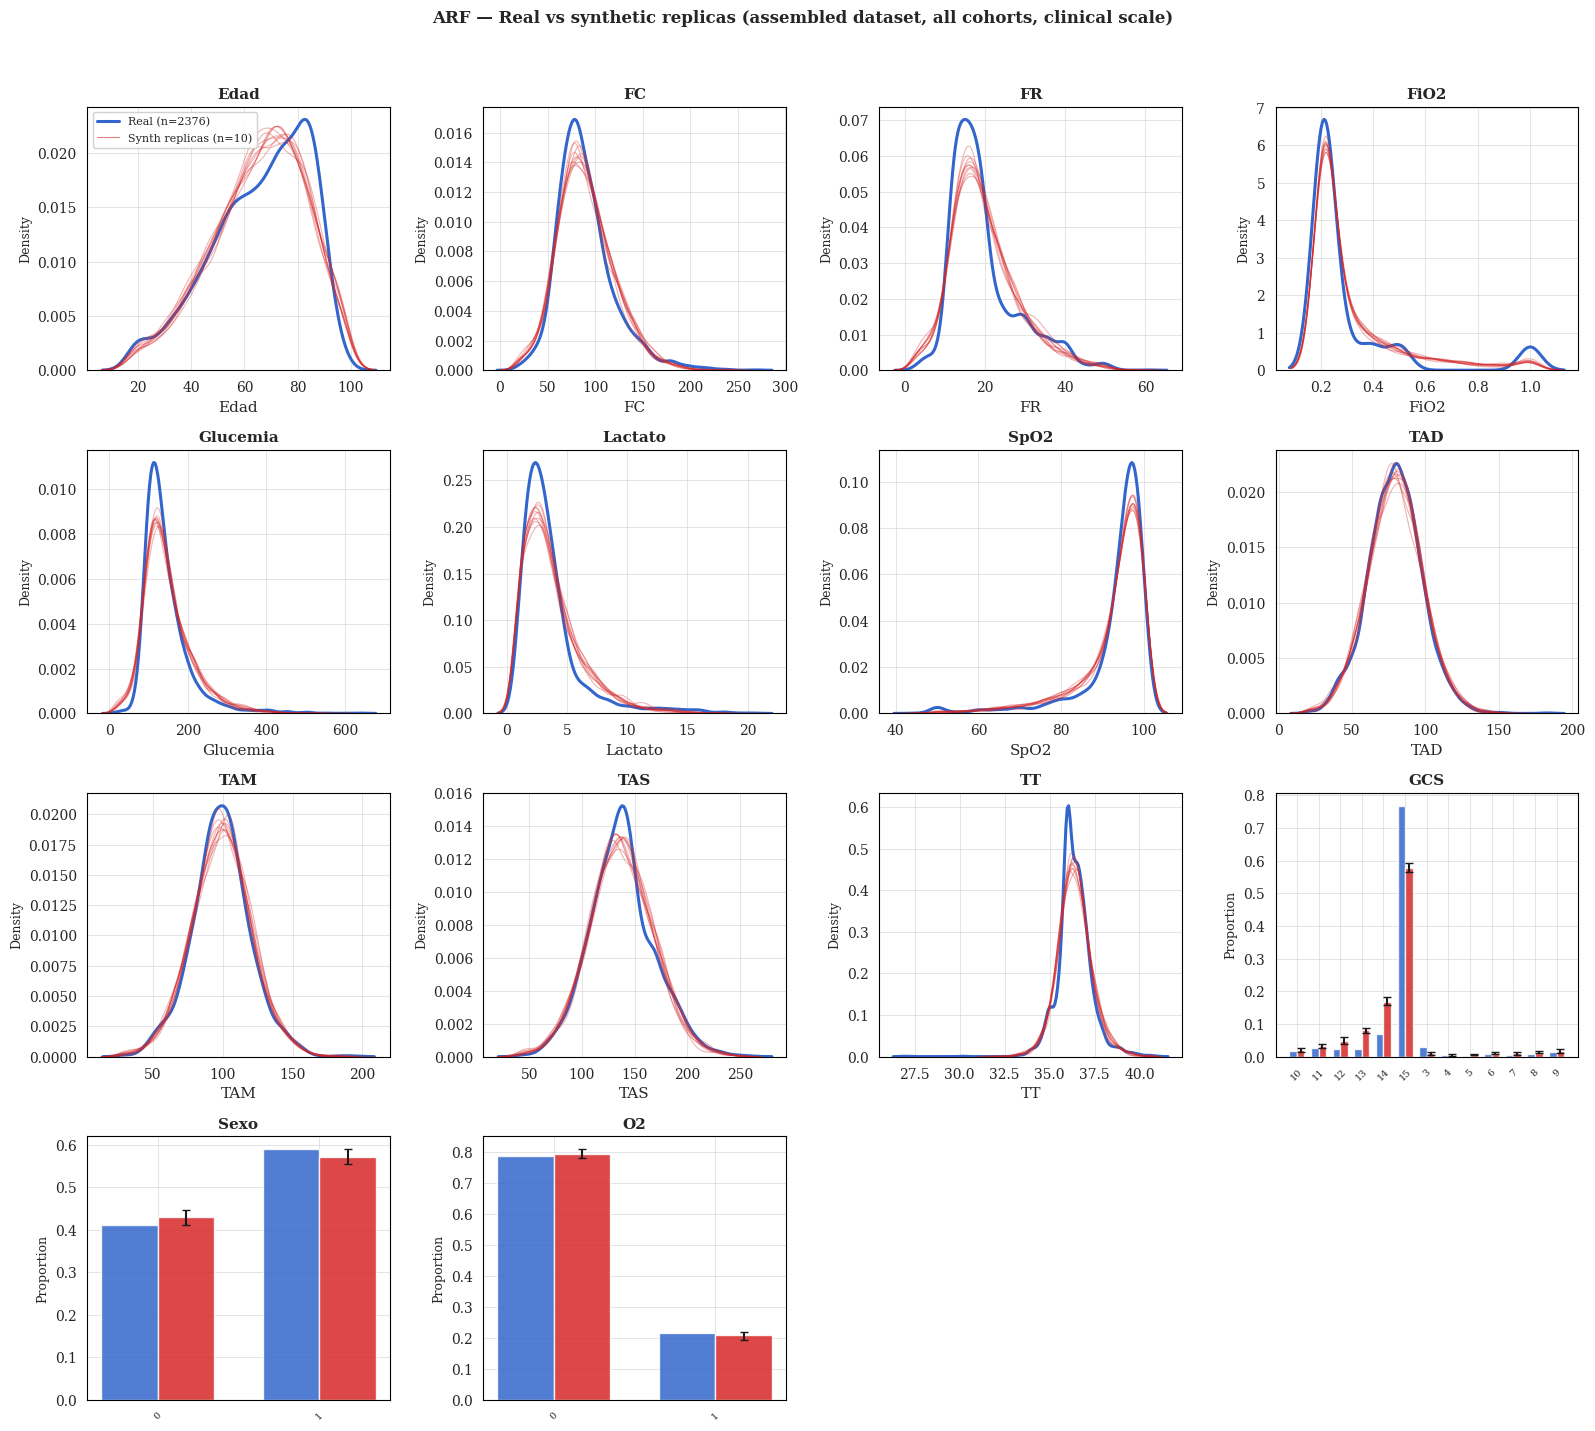

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 14 — Global distribution comparison: Real vs N synthetic replicas
#
# For each variable, one subplot with:
#   - Real distribution (dataset_FINAL.csv, 2 376 patients) as a thick blue
#     reference trace.
#   - N_SYNTH_DATASETS synthetic replicas overlaid as thin, transparent traces.
#     Visualises both average fidelity and inter-replica variance in a single
#     figure per generator.
#
# Synthetic reference: assembled_datasets (all replicas).
#   = all four exclusive cohorts concatenated (Mort. 2D, Mort. 7D excl.,
#   Mort. 30D excl., Survivors) — the broadest non-duplicating synthetic
#   population, directly comparable to the full real dataset (2 376 patients).
#
# Continuous variables: KDE overlay (all replicas superimposed)
# Discrete variables:   grouped bar chart (mean + min/max range across replicas)
# Mirrors NB6 section 10 for direct cross-generator visual comparison.
# ══════════════════════════════════════════════════════════════════════════════

if CFG_PLOT:

    discrete_set       = set(BINARY_COLS + CATEGORICAL_COLS + ORDINAL_COLS + OUTCOMES)
    DISCRETE_PLOT_COLS = ["GCS", "Sexo", "O2"]

    # Collect all replicas of the assembled endpoint dataset
    assembled_replicas = assembled_datasets   # list of N_SYNTH_DATASETS DataFrames, all 4 cohorts

    # Reference columns: must exist in both real and every replica
    cont_cols_global = [c for c in CONTINUOUS_COLS
                        if c in df_real.columns
                        and all(c in d.columns for d in assembled_replicas)]
    disc_cols_global = [c for c in DISCRETE_PLOT_COLS
                        if c in df_real.columns
                        and all(c in d.columns for d in assembled_replicas)]
    all_cols_global  = cont_cols_global + disc_cols_global

    # ── Build figure ──────────────────────────────────────────────────────────
    n_c = 4
    n_r = int(np.ceil(len(all_cols_global) / n_c))
    fig, axes = plt.subplots(n_r, n_c, figsize=(4 * n_c, 3.5 * n_r))
    axes = axes.flatten()

    for i, col in enumerate(all_cols_global):
        ax = axes[i]

        if col in discrete_set:
            # ── Grouped bar chart: mean + min/max range across replicas ────────
            rc   = df_real[col].astype(str).value_counts(normalize=True).sort_index()
            cats = list(rc.index)
            x    = np.arange(len(cats))
            width = 0.35

            ax.bar(x - width / 2, rc.values, width,
                   color=COLOUR_REAL, alpha=0.85,
                   label=f"Real (n={len(df_real)})")

            rep_mat = np.vstack([
                d[col].astype(str).value_counts(normalize=True)
                 .reindex(cats, fill_value=0.0).values
                for d in assembled_replicas
            ])
            mean_prop = rep_mat.mean(axis=0)
            lo        = rep_mat.min(axis=0)
            hi        = rep_mat.max(axis=0)

            ax.bar(x + width / 2, mean_prop, width,
                   color=COLOUR_SYNTH, alpha=0.85,
                   yerr=[mean_prop - lo, hi - mean_prop], capsize=3,
                   label=f"Synth mean ± range (n={N_SYNTH_DATASETS} replicas)")
            ax.set_xticks(x)
            ax.set_xticklabels(cats, rotation=45, fontsize=7)
            ax.set_ylabel("Proportion", fontsize=9)

        else:
            # ── KDE overlay: all replicas as thin transparent traces ───────────
            rv = pd.to_numeric(df_real[col], errors="coerce").dropna()
            sns.kdeplot(rv, ax=ax, color=COLOUR_REAL,
                        linewidth=2.2, label=f"Real (n={len(rv)})")
            for d in assembled_replicas:
                sv = pd.to_numeric(d[col], errors="coerce").dropna()
                sns.kdeplot(sv, ax=ax, color=COLOUR_SYNTH,
                            linewidth=0.8, alpha=0.35)
            # Phantom trace for a unified legend entry
            ax.plot([], [], color=COLOUR_SYNTH, linewidth=0.8, alpha=0.6,
                    label=f"Synth replicas (n={N_SYNTH_DATASETS})")
            ax.set_ylabel("Density", fontsize=9)

        ax.set_title(col, fontsize=11)
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(len(all_cols_global), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        "ARF — Real vs synthetic replicas (assembled dataset, all cohorts, clinical scale)",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    fig_path_global = os.path.join(FIGS_OUT, "fig_replicas_vs_real.png")
    fig.savefig(fig_path_global, dpi=150, bbox_inches="tight")
    print(f"\u2713 Saved: {fig_path_global}")
    plt.show()

else:
    print("Skipping global comparison plot (CFG_PLOT = False).")


## **15. Export synthetic datasets**

Output artefacts are written to `GENERATION/DATASET_ARF/`:

**Per replica → `dsXX/` folder:**

| File | Description |
|------|-------------|
| `dataset_SYNTH_ARF.csv` | All 4 exclusive cohorts concatenated (clinical scale) → NB8 fidelity, NB9 TSTR |

**Shared files (root of `GEN_DIR`):**

| File | Description |
|------|-------------|
| `dataset_TEST.csv` | Deduplicated real test partitions (clinical scale, shared across replicas) |
| `cohorts/cohort_<name>.csv` | **Real training partitions** per cohort used as reference by NB8 / NB10 |
| `synthetic_cohorts_ds01/cohort_<name>.csv` | Synthetic cohorts from replica ds01 only — optional diagnostic artefact, not used as reference |
| `generation_metadata.json` | Generator provenance, split parameters, cohort sizes → NB8 |
| `figures/fig_replicas_vs_real.png` | Global Real vs synthetic distribution comparison |

The test set is exported alongside the synthetic data so that downstream
notebooks (NB8, NB9) can load both from a single directory. With exclusive
cohorts there are no structural duplicate patients across test partitions;
`drop_duplicates()` is retained as a safety guard.

**NB9** TSTR classifiers select the relevant target column (Mort. 2D / 7D / 30D)
directly from `dataset_SYNTH_ARF.csv`; no separate endpoint files are needed.

Full output path: `/content/DATASET_ARF/`


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# section 15 — Export
# ══════════════════════════════════════════════════════════════════════════════
exported_files = []

# ── Output directories ────────────────────────────────────────────────────────
SYNTH_COHORTS_OUT = os.path.join(GEN_DIR, "synthetic_cohorts_ds01")
os.makedirs(COHORTS_OUT,       exist_ok=True)
os.makedirs(SYNTH_COHORTS_OUT, exist_ok=True)

# ── 1. Per-replica assembled synthetic datasets ────────────────────────────
# Each replica gets its own subdirectory (ds01/, ds02/, ...).
# The assembled dataset = all 4 exclusive cohorts concatenated (clinical scale).
for ds_idx in range(N_SYNTH_DATASETS):
    ds_label = f"ds{ds_idx + 1:02d}"
    ds_dir   = os.path.join(GEN_DIR, ds_label)
    os.makedirs(ds_dir, exist_ok=True)

    df_assembled   = assembled_datasets[ds_idx]
    assembled_path = os.path.join(ds_dir, "dataset_SYNTH_ARF.csv")
    df_assembled.to_csv(assembled_path, index=False)
    exported_files.append(assembled_path)
    print(f"\u2713 Replica {ds_label}: {assembled_path}  {df_assembled.shape}")

# ── 2. Real training cohorts → cohorts/ (reference for NB8 / NB10) ────────
# NB8 and NB10 read cohorts/ as the real training reference.
# Export the actual training partition (train_full) aligned to FINAL_EXPORT_COLS.
for cohort_name in cohorts.keys():
    safe_name      = cohort_name.replace(" ", "_").replace(".", "")
    df_real_cohort = cohort_splits[cohort_name]["train_full"].copy()
    # Align to FINAL_EXPORT_COLS where available; keep all columns otherwise.
    export_cols    = [c for c in FINAL_EXPORT_COLS if c in df_real_cohort.columns]
    df_real_cohort = df_real_cohort[export_cols]
    path           = os.path.join(COHORTS_OUT, f"cohort_{safe_name}.csv")
    df_real_cohort.to_csv(path, index=False)
    exported_files.append(path)
    print(f"\u2713 Real cohort   {cohort_name:<12}: {path}  {df_real_cohort.shape}")

# ── 3. Synthetic cohorts from ds01 → synthetic_cohorts_ds01/ (diagnostics) ──
# Kept for optional visual / distributional inspection; never used as reference.
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    df_syn    = synthetic_cohort_full[cohort_name][0]
    path      = os.path.join(SYNTH_COHORTS_OUT, f"cohort_{safe_name}.csv")
    df_syn.to_csv(path, index=False)
    exported_files.append(path)
    print(f"\u2713 Synth cohort  {cohort_name:<12}: {path}  {df_syn.shape}")

# ── 4. Test set (shared across replicas, deduplicated) ─────────────────────
# With exclusive cohorts, test partitions do not overlap structurally.
# drop_duplicates() is retained as a safety guard.
test_frames = [
    cohort_splits[c]["test_full"]
    for c in cohorts.keys()
    if len(cohort_splits[c]["test_full"]) > 0
]
df_test    = pd.concat(test_frames, ignore_index=True).reset_index(drop=True)
test_path  = os.path.join(GEN_DIR, "dataset_TEST.csv")
df_test.to_csv(test_path, index=False)
exported_files.append(test_path)
print(f"\u2713 Test set: {test_path}  {df_test.shape}")

# ── 5. Sanity check: cohorts/ must NOT be a copy of ds01 synthetic data ────
# Reads back cohorts/ and computes the fraction of rows that are exact matches
# with ds01. If the overlap is near 100 %, the real reference was not written
# correctly and downstream privacy metrics will be invalid.
_real_ref_parts = []
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    _path     = os.path.join(COHORTS_OUT, f"cohort_{safe_name}.csv")
    _real_ref_parts.append(pd.read_csv(_path))
_df_ref_check = pd.concat(_real_ref_parts, ignore_index=True)
_df_ds01      = assembled_datasets[0]

_common_cols  = [c for c in _df_ref_check.columns if c in _df_ds01.columns]
_ref_tuples   = set(map(tuple, _df_ref_check[_common_cols].values.tolist()))
_ds01_tuples  = set(map(tuple, _df_ds01[_common_cols].values.tolist()))
_overlap_n    = len(_ref_tuples & _ds01_tuples)
_overlap_pct  = 100.0 * _overlap_n / max(len(_ref_tuples), 1)

print(f"\n{'─' * 60}")
print(f"Sanity check — cohorts/ vs ds01:")
print(f"  cohorts/ rows  : {len(_df_ref_check)}")
print(f"  ds01 rows      : {len(_df_ds01)}")
print(f"  Exact overlap  : {_overlap_n} rows  ({_overlap_pct:.1f} %)")
if _overlap_pct > 50.0:
    raise RuntimeError(
        f"EXPORT ERROR: cohorts/ shares {_overlap_pct:.1f} % of rows with ds01 "
        f"synthetic data. Real training partitions were NOT written correctly."
    )
else:
    print(f"  \u2713 cohorts/ is distinct from ds01 — real reference export verified.")
print(f"{'─' * 60}")

# ── Final output tree summary ─────────────────────────────────────────────
df0 = assembled_datasets[0]
print(f"\n{'═' * 84}")
print(f"  OUTPUT DIRECTORY: {GEN_DIR}")
print(f"{'─' * 84}")
print(f"  DATASET_ARF/")
for ds_idx in range(N_SYNTH_DATASETS):
    ds_label = f"ds{ds_idx + 1:02d}"
    df_ds    = assembled_datasets[ds_idx]
    print(f"  ├── {ds_label}/dataset_SYNTH_ARF.csv  ({df_ds.shape[0]:>5} × {df_ds.shape[1]})")
print(f"  ├── dataset_TEST.csv            ({df_test.shape[0]:>5} × {df_test.shape[1]})")
print(f"  ├── cohorts/                    (real training reference for NB8/NB10)")
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    print(f"  │   ├── cohort_{safe_name}.csv")
print(f"  ├── synthetic_cohorts_ds01/     (diagnostic only — NOT a reference)")
for cohort_name in cohorts.keys():
    safe_name = cohort_name.replace(" ", "_").replace(".", "")
    print(f"  │   ├── cohort_{safe_name}.csv")
print(f"  ├── figures/fig_replicas_vs_real.png")
print(f"  └── generation_metadata.json")
print(f"{'═' * 84}")
print(f"\u2713 {len(exported_files)} file(s) exported successfully.")
print(f"\n{'═' * 84}")
print("  NB7 — ARF generation complete.")
print(f"{'═' * 84}")

✓ Replica ds01: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds01/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds02: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds02/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds03: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds03/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds04: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds04/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds05: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds05/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds06: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds06/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds07: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds07/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds08: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/ds08/dataset_SYNTH_ARF.csv  (1781, 33)
✓ Replica ds09: /content/drive/M

In [ ]:
# ════════════════════════════════════════════
# section 15.1 — Export generation metadata (NB8 / NB9 compatibility)
# ════════════════════════════════════════════
# Writes generation_metadata.json to GEN_DIR.
# NB8 loads this file to:
#   (a) reconstruct the exact train_ref[cohort] used by ARF
#   (b) verify cohort sizes match the reconstruction
#   (c) associate each dsXX/ subdirectory with its generation seed
#
# NOTE: ARF has no survivor cap — survivors["cap_applied"] is always False.
# Schema matches NB6 section 12.1 for cross-generator comparability in NB8.
# ────────────────────────────────────────────

from datetime import datetime as _dt

# ── Cohort size summary ────────────────────────────────────────────
_cohort_sizes = {
    name: {
        "n_full":  int(len(info["df_full"])),
        "n_train": int(cohort_splits[name]["sizes"]["train"]),
        "n_test":  int(cohort_splits[name]["sizes"]["test"]),
        "n_synth": int(len(synthetic_cohort_full.get(name, [[]])[0])
                       if synthetic_cohort_full.get(name) else 0),
    }
    for name, info in cohorts.items()
}

_surv_full_n = len(
    df_typed.loc[
        (df_typed["Mort. 2D"] == 0) &
        (df_typed["Mort. 7D"] == 0) &
        (df_typed["Mort. 30D"] == 0)
    ]
)

generation_metadata = {
    "generator":   "ARF",
    "notebook":    "NB7",
    "version":     "V7_4",
    "source_file": "dataset_FINAL.csv",
    "environment": collect_environment_metadata(),
    "export_layout": {
        "version": "per_replica_assembled_plus_real_cohorts_reference",
        "files_per_replica": [
            "dataset_SYNTH_ARF.csv",
        ],
        "shared_files": ["dataset_TEST.csv", "generation_metadata.json",
                         "figures/fig_replicas_vs_real.png",
                         "cohorts/cohort_<name>.csv",
                         "synthetic_cohorts_ds01/cohort_<name>.csv"],
        "cohort_files_role": "cohorts/ contains real training partitions used as reference by NB8/NB10; synthetic_cohorts_ds01/ contains synthetic cohorts from replica ds01 for diagnostics only",
    },
    "type_map": {
        "continuous_columns":  list(CONTINUOUS_COLS),
        "binary_columns":      list(BINARY_COLS),
        "categorical_columns": list(CATEGORICAL_COLS),
        "ordinal_columns":     list(ORDINAL_COLS),
        "outcome_columns":     list(OUTCOMES),
    },
    "split": {
        "random_seed": int(RANDOM_SEED),
        "train_ratio": float(TRAIN_RATIO),
        "min_size":    int(SPLIT_MIN_SIZE),
    },
    "survivors": {
        "cap_applied": False,
        "cap_n":       None,
        "cap_seed":    None,
        "n_full":      int(_surv_full_n),
        "n_used":      int(_surv_full_n),
    },
    "cohort_sizes": _cohort_sizes,
    "replicas": {
        "n_datasets":    int(N_SYNTH_DATASETS),
        "seeds":         [int(s) for s in REPLICA_SEEDS[:N_SYNTH_DATASETS]],
        "seed_strategy": "SeedSequence(RANDOM_SEED).spawn(N_SYNTH_DATASETS) for FORGE sampling; NumPy seed set before each cohort fit",
    },
    "generation_timestamp": _dt.now().isoformat(timespec="seconds"),
}

meta_path = os.path.join(GEN_DIR, "generation_metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(generation_metadata, f, indent=2, default=str)

print(f"Metadata written: {meta_path}")
print(f"  version      : {generation_metadata['version']}")
print(f"  export_layout: {generation_metadata['export_layout']['version']}")
print(f"  type_map keys: {list(generation_metadata['type_map'].keys())}")
print(f"  replicas     : {generation_metadata['replicas']['n_datasets']}")
print(f"  seeds[0]     : {generation_metadata['replicas']['seeds'][0]}")
print("  Cohort sizes:")
for _name, _sz in _cohort_sizes.items():
    print(f"    {_name:<12}: n_train={_sz['n_train']:>4}  n_test={_sz['n_test']:>4}  n_synth={_sz['n_synth']:>4}")

os.remove('/content/dataset_FINAL.csv')


Metadata written: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/generation_metadata.json
  version      : V7_4
  export_layout: per_replica_assembled_plus_real_cohorts_reference
  type_map keys: ['continuous_columns', 'binary_columns', 'categorical_columns', 'ordinal_columns', 'outcome_columns']
  replicas     : 10
  seeds[0]     : 2684470948
  Cohort sizes:
    Mort. 2D    : n_train=  85  n_test=  29  n_synth=  85
    Mort. 7D    : n_train=  44  n_test=  15  n_synth=  44
    Mort. 30D   : n_train=  66  n_test=  22  n_synth=  66
    survivors   : n_train=1586  n_test= 529  n_synth=1586
